objective

To build a Comvolutional Autoencoder(CAE) that compresses facial images into a lower-dimensional latert representation and reconstructs them with minimal loss of information

purpose

A convolution Autoencoder is an unsupervised deep learning model used for: image compression image reconstruction feature extraction dimensionality reduction The Encoder learns compressed represenatation (latent Space), while the decoder reconsructs the original image from the compressed represenatation

In [ ]:
import os
import shutil
import numpy  as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2D

In [ ]:
!pip install -q kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
import os
import shutil

source_folder= os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder="celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder, image),
      destination_folder
      )
  print("Copied", len(image), "image")

Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 1

In [ ]:
#Data Preprocessing

IMAGE_SIZE = (64, 64)

BATCH_SIZE = 32

In [ ]:
datagen= ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2)

In [ ]:
#load dataset

train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


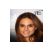

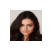

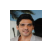

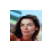

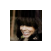

In [ ]:
images, _= next(train_generator)

plt.figure(figsize=(10, 5))
for i in range(5):
  plt.subplot(10, 5, i+1)
  plt.imshow(images[i])
  plt.axis("off")
  plt.show()

In [ ]:
input_img = Input(shape=(64, 64, 3))

x = Conv2D(
    32,
     (3, 3),
    activation="relu",
    padding="same"
)(input_img)
x = MaxPooling2D((2, 2), padding="same")(x)
x = Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)
encoded = MaxPooling2D(
      (2, 2),
      padding="same"
)(x)

# Decoder starts from the 'encoded' layer
x = Conv2D(
    64,
    (3, 3),
    activation='relu',
    padding='same'
)(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(
    3,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)

In [ ]:
# create Model
autoencoder = Model(
    input_img,
    decoded
)

In [ ]:
#Complie Model
autoencoder.compile(
    optimizer='adam',
    loss = 'binary_crossentropy'
)

In [ ]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,723 (151.26 KB)

 Trainable params: 38,723 (151.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history =  autoencoder.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4825 - val_loss: 0.4823
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4823 - val_loss: 0.4822
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4824 - val_loss: 0.4820
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.4818 - val_loss: 0.4847
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4820 - val_loss: 0.4815
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4817 - val_loss: 0.4815
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.4811 - val_loss: 0.4817
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.4810 - val_loss: 0.4808
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.4815 - val_loss: 0.4813
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4807 - val_loss: 0.4807


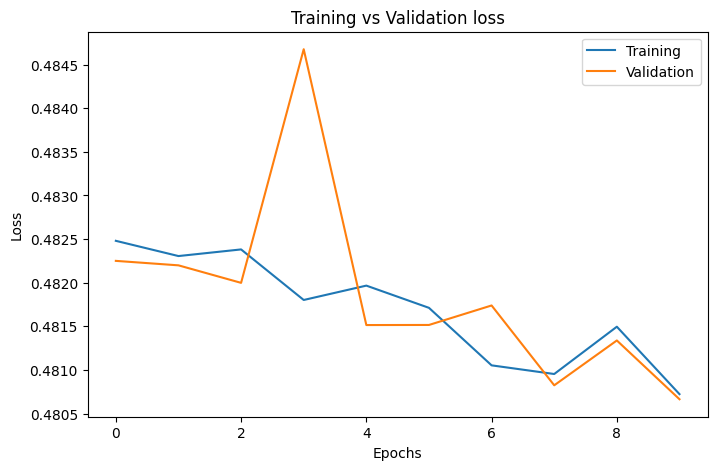

In [ ]:
#Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation loss")
plt.legend(["Training","Validation"])
plt.show()

In [ ]:
#evaluate model
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4807
Validation Loss: 0.48066478967666626


In [ ]:
#reconstruct images
image,_ = next(validation_generator)
Decoded_images = autoencoder.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step


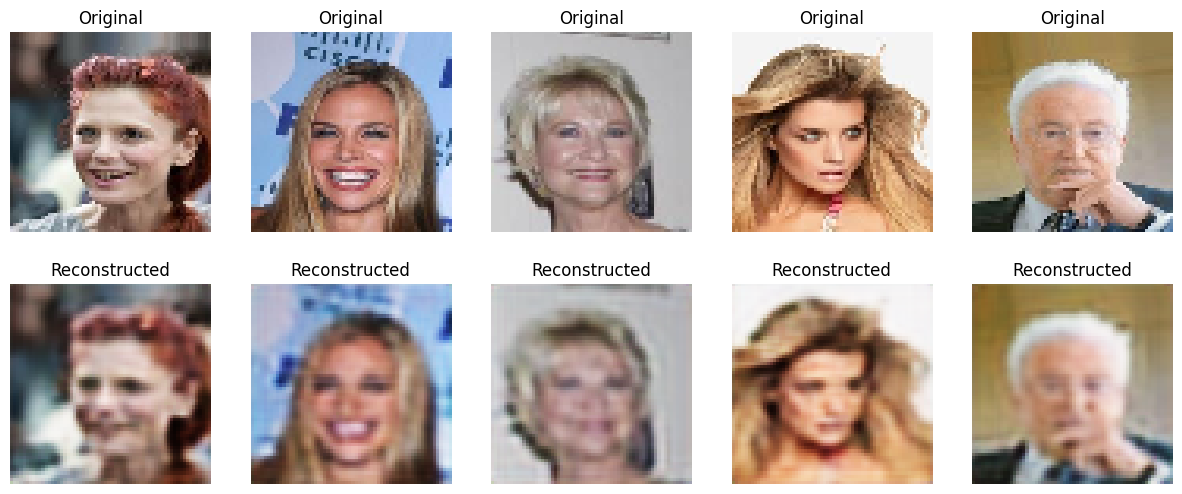

In [ ]:
#display result
n = 5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(image[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+1+n)
  plt.imshow(Decoded_images[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()

In [ ]:
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.4807
Validation Loss: 0.48066478967666626
